In [2]:
%load_ext autoreload
%autoreload 2

### Setup

In [3]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts'))
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts/scaling'))

import pandas as pd
import numpy as np

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [4]:
pull_predictions_from_weka("aws")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_aws_predictions.parquet


In [5]:
# df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet.bak') # <- 12/11 only OLMES

COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id'] 
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice'] # accuracy benchmarks
# COLS += ['exact_match', 'f1'] # generation benchmarks
# exact_match_simple, recall

df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet', columns=COLS)

print(f'Loaded {len(df):,} instance predictions')

Loaded 81,658,165 instance predictions


In [6]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()

TASKS = [t for t in TASKS if 'mmlu' not in t]
TASKS = sorted(TASKS)

print(MODELS)
print(TASKS)
print(MIXES)
# print(STEPS)

['peteish-moreeval-1B-5xC', 'peteish-moreeval-760M-0.5xC', 'peteish-moreeval-rerun-370M-1xC', 'phi-1_5', 'peteish13-highlr', 'peteish-moreeval-190M-2xC', 'peteish-moreeval-rerun-190M-1xC', 'peteish-moreeval-1B-2xC', 'peteish7', 'falcon_and_cc_eli5_oh_top10p-1B-5xC', 'fineweb_edu_dedup-1B-5xC', 'falcon_and_cc_og_eli5_oh_top10p-1B-5xC', 'falcon_and_cc-1B-5xC', 'no_flan-1B-5xC', 'prox_fineweb_pro-1B-5xC', 'falcon_and_cc_eli5_oh_top20p-1B-5xC', 'baseline-1B-5xC', 'falcon_and_cc_tulu_qc_top10-1B-5xC', 'no_math_no_code-1B-5xC', 'c4-1B-5xC', 'redpajama-1B-5xC', 'no_code-1B-5xC', 'no_reddit-1B-5xC', 'falcon-1B-5xC', 'peteish-moreeval-rerun-760M-1xC', 'peteish-moreeval-370M-2xC', 'DCLM-baseline-1B-5xC', 'dolma17-25p-DCLM-baseline-75p-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-1B-5xC', 'dolma-v1-6-and-sources-baseline-1B-5xC', 'dolma17-75p-DCLM-baseline-25p-1B-5xC', 'peteish-moreeval-760M-10xC', 'peteish-moreeval-3B-10xC', 'peteish-moreeval-rerun-3B-1xC', 'peteish-moreeval-rerun-1B-1xC', 'peteish-m

In [7]:
# models, scores = get_nd_array(df, 'model', 'acc_per_char', task='arc_challenge:distractors')
# models, scores = get_nd_array(df, ['model', 'mix'], 'acc_per_char', task='arc_challenge:distractors')

In [8]:
# OLMES Classic Tasks
from utils.constants_tasks import RC_TASKS_OLMES, PARA_TASKS_OLMES, ENLARGE_TASKS_OLMES, DISTRACTORS_TASKS_OLMES

# OLMES Gen Tasks
from utils.constants_tasks import GEN_TASKS_OLMES, GEN_TASKS_OLMES_PERTURB_RC

# CoT tasks (mainly Tulu tasks)
from utils.constants_tasks import AGI_EVAL_MC, AGI_EVAL_COT
from utils.constants_tasks import MMLU_PRO_MC, MMLU_PRO_RC, MMLU_PRO_COT
from utils.constants_tasks import MINERVA_MC, MINERVA_COT
from utils.constants_tasks import BBH_MC, BBH_COT
from utils.constants_tasks import PERTURB_COT_TASKS

def task_tag(task_name):
    return task_name.split('::')[0].replace(':rc', '')

# Select task set
selected_tasks = RC_TASKS_OLMES + PARA_TASKS_OLMES + ENLARGE_TASKS_OLMES + DISTRACTORS_TASKS_OLMES
# selected_tasks = MC_TASKS_COPY_COLORS
# selected_tasks = GEN_TASKS_OLMES + GEN_TASKS_OLMES_PERTURB_RC
# selected_tasks = AGI_EVAL_MC + AGI_EVAL_COT + MMLU_PRO_MC + MMLU_PRO_RC + MMLU_PRO_COT + MINERVA_COT + BBH_MC + BBH_COT + PERTURB_COT_TASKS

TASKS = [task_tag(task) for task in selected_tasks]

TASKS = [task for task in TASKS if 'mmlu_' not in task]

# Get task suites
olmes = [task_tag(task) for task in RC_TASKS_OLMES if 'mmlu_' not in task]

# TODO: Add olmes_avg and it's variants to TASKS
# TODO: Add mmlu macro avg as a single task!

### Measure 1: Predictability (Rel Error @ 7B)

In [9]:
import matplotlib.pyplot as plt

# https://arxiv.org/pdf/2412.04403#page=3.57
LADDER_MODELS = [model for model in MODELS if 'peteish-moreeval' in model]

# For the paper, we did not use 3B or 0.5xC models
akshita_ladder_models = [
    model for model in LADDER_MODELS if "3B" not in model and "0.5xC" not in model
]

In [10]:
from ladder import get_ladder_data
plt.close('all') # silence output

# Example of grabbing ladder data
data_by_name = get_ladder_data(
    df, task_name="arc_challenge", train_models=LADDER_MODELS, eval_models=["peteish7"]
)

In [11]:
# Sanity check for task results
task_name = 'arc_challenge:distractors'
model = 'peteish13-highlr'
m2, bpb  = get_nd_array(df, 'model', 'logits_per_byte', model=model, task=task_name, step='max')
data_by_name = get_ladder_data(df, [task_name], LADDER_MODELS, [model])

defaultdict(<class 'dict'>, {'1.3B': {'xs': [0.8621499997648778, 0.9138312688005634, 0.9608929237730812, 0.8258176504178892], 'ys': [0.38054607508532423, 0.3455631399317406, 0.3174061433447099, 0.39590443686006827], 'mode': 'train'}, '370M': {'xs': [1.1116021845928756, 1.0544780869447665, 0.9726235782554774, 0.9985378560734545], 'ys': [0.2627986348122867, 0.257679180887372, 0.3003412969283277, 0.29436860068259385], 'mode': 'train'}, '190M': {'xs': [1.1927781860134712, 1.2547404595397103, 1.1195039551207302, 1.088512483158631], 'ys': [0.2440273037542662, 0.23976109215017063, 0.2508532423208191, 0.25426621160409557], 'mode': 'train'}, '760M': {'xs': [1.0208840925899247, 0.8854799316136344, 0.958217895468796, 0.9190122189794692], 'ys': [0.2551194539249147, 0.34812286689419797, 0.31143344709897613, 0.34215017064846415], 'mode': 'train'}, '7B-4T': {'xs': [0.6883274123293449], 'ys': [0.5793515358361775], 'mode': 'eval'}})
[-0.77607248  0.66140421  7.09872059  1.        ]


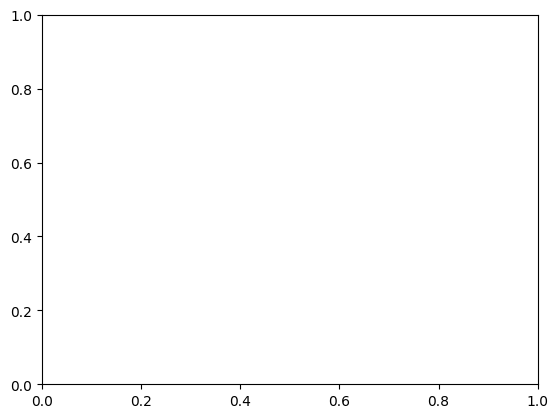

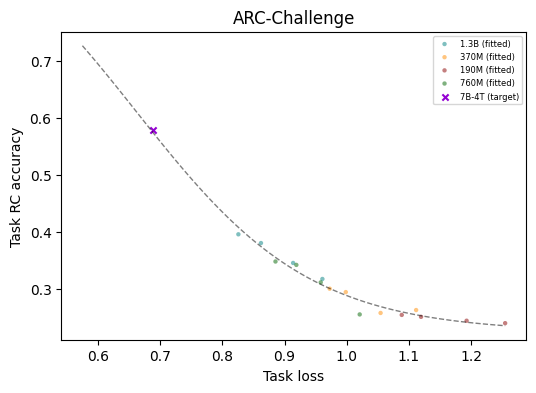

In [32]:
from ladder import run_ladder

# python scripts/scaling/step2.py -k v2_main -c scripts/scaling/step2.json -o figure/peteish-moreeval/step2_main.pdf --skip_perc 1

ladder_config_path = f'{ROOT_DIR}/olmo-repos/OLMo/scripts/scaling/final_moredata.json'

fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)
run_ladder(
    df,
    train_models=akshita_ladder_models,
    eval_models=["peteish7"],
    task_name="arc_challenge",
    # eval_models=["peteish13-highlr"],
    # task_name="agi_eval_aqua-rat:perturb_cot",
    config_path=ladder_config_path,
    axes=[axes[0][0]],
    run_step1=False, run_stacked=False
)
_ = axes[0][0].set_title('ARC-Challenge')

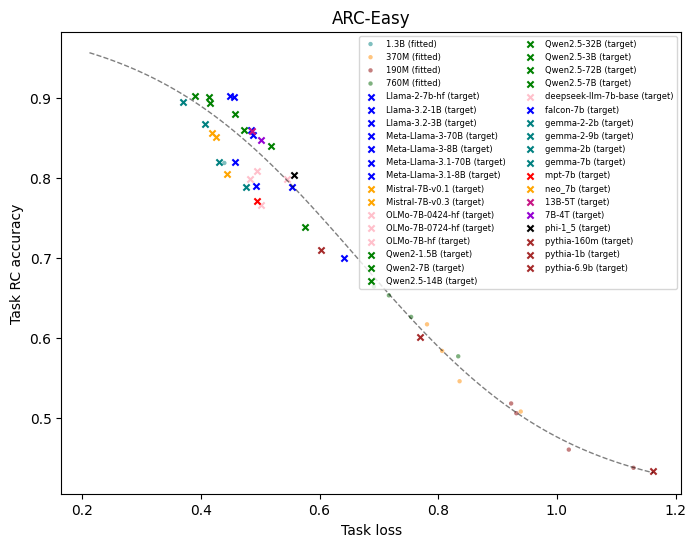

In [64]:
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split("/")[-1] for model in MODEL_LIST_MIXES]
BROKEN_MODELS = ['Llama-2-13b-hf']
all_models = sorted([model for model in MODELS if model not in MODEL_LIST_MIXES + BROKEN_MODELS + LADDER_MODELS])

fig, axes = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)
run_ladder(
    df,
    task_name="arc_easy",
    # task_name=[olmes],
    train_models=akshita_ladder_models,
    eval_models=all_models,
    config_path=ladder_config_path,
    axes=[axes[0][0]],
    run_step1=False, run_stacked=False
)
# axes[0][0].set_title('OLMES Average')
axes[0][0].set_title('ARC-Easy')
_ = axes[0][0].legend(fontsize=6, ncol=2)

In [67]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 1
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=['rel_error'], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    ax: plt.Axes = axes[i, 0]

    try:
        _, rel_error_step_2, _ = run_ladder(
            df, 
            task_name=task, 
            train_models=akshita_ladder_models, 
            # eval_models=['peteish7'], 
            eval_models=['peteish13-highlr'], 
            config_path=ladder_config_path,
            axes=[ax],
            run_step1=False, run_stacked=False
        )

        ax.set_title(task)
        ax.legend(fontsize=4, ncol=2)

        task_name = task
        if isinstance(task, list):
            task_name = 'olmes_macro_average'

        fitting_results.loc['rel_error', task_name] = abs(rel_error_step_2)
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

plt.close(fig)

Fitting model ladder predictions: 100%|██████████| 34/34 [00:29<00:00,  1.16it/s]


In [68]:
from table import display_task_variants

print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.9%,4.3% (+3.4%),3.9% (+3.0%),3.4% (+2.5%)
piqa,1.0%,18.1% (+17.1%),1.4% (+0.4%),1.5% (+0.6%)
arc_easy,3.1%,2.5% (-0.6%),8.0% (+4.9%),2.6% (-0.5%)
csqa,3.6%,9.2% (+5.6%),2.7% (-0.9%),1.5% (-2.2%)
socialiqa,4.8%,20.3% (+15.5%),2.1% (-2.7%),7.6% (+2.8%)
arc_challenge,5.9%,7.5% (+1.7%),8.3% (+2.5%),6.5% (+0.7%)
openbookqa,7.9%,1.2% (-6.7%),4.3% (-3.7%),9.8% (+1.8%)
boolq,13.9%,11.6% (-2.3%),2.0% (-11.9%),16.1% (+2.2%)
winogrande,26.5%,--,--,20.3% (-6.1%)


### Measure 2: Seperability (% sig @ 1B)

Explanation of a paired permutation test:


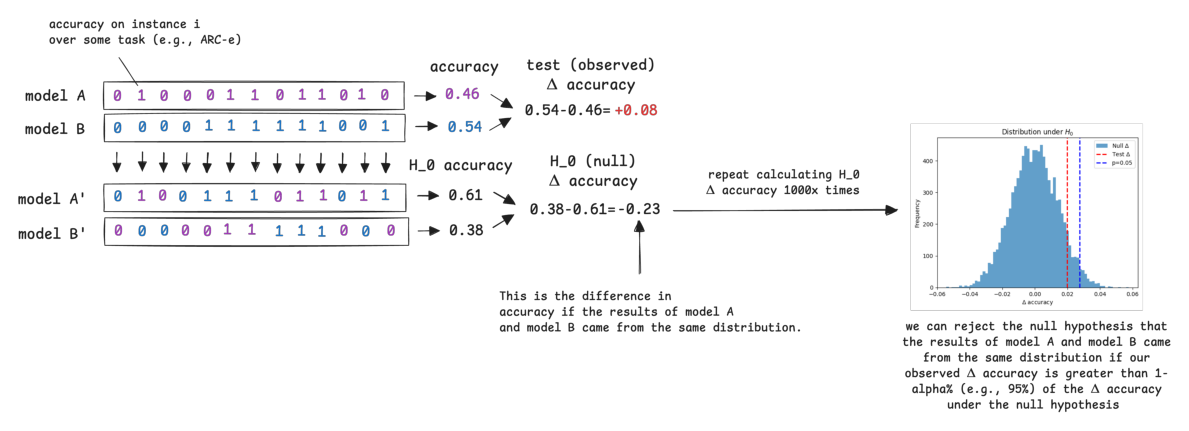

In [69]:
from PIL import Image
import matplotlib.pyplot as plt

def display_image(path, max_width=1200):
    img = Image.open(path)
    plt.figure(figsize=(min(max_width/100, img.width/100), img.height/100))
    plt.imshow(plt.imread(path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()


print('Explanation of a paired permutation test:')
os.chdir('/Users/dhei/ai2/new-evals/analysis/notebooks')
display_image('assets/paired-permutation-test.png')

In [70]:
from stats import compute_significance
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split('/')[-1] for model in MODEL_LIST_MIXES]

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s]


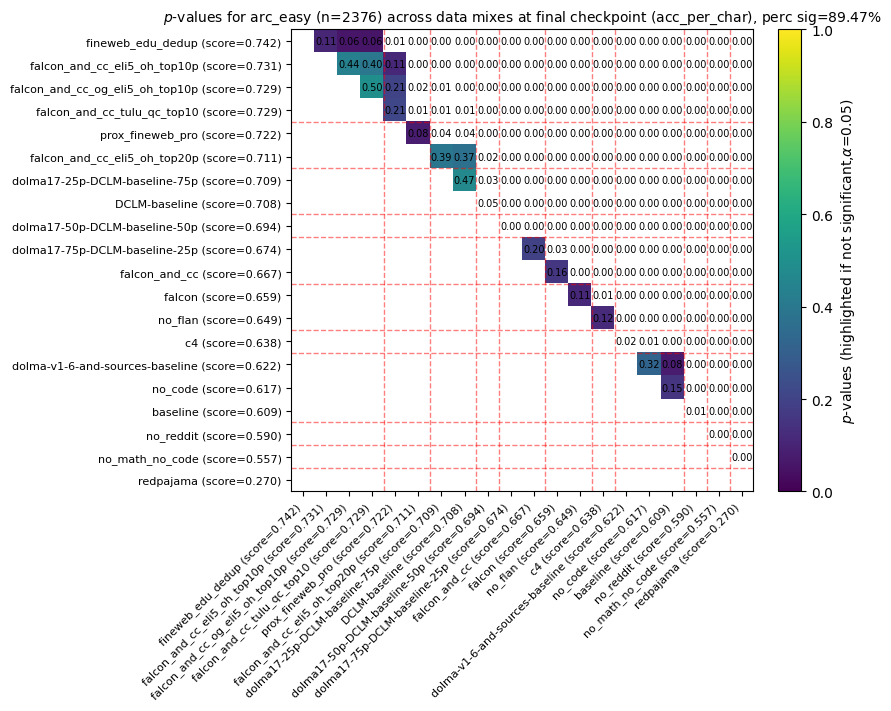

In [71]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)

sig_results, _, ax = compute_significance(
    df, 
    models=MODEL_LIST_MIXES, 
    metric='acc_per_char', 
    tasks=['arc_easy'], 
    do_plot=axes[0][0]
)

In [72]:
sig_results, _, _ = compute_significance(
    df, 
    models=MODEL_LIST_MIXES, 
    metric='acc_per_char', 
    # tasks='arc_easy',
    tasks=TASKS,
    do_plot=False
)

Computing pairwise comparisons: 100%|██████████| 34/34 [00:19<00:00,  1.75it/s]


In [73]:
from table import display_task_variants

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,89.5%,91.1% (+1.6%),95.3% (+5.8%),84.7% (-4.7%)
hellaswag,86.3%,59.5% (-26.8%),77.9% (-8.4%),79.5% (-6.8%)
csqa,79.5%,81.6% (+2.1%),93.7% (+14.2%),51.6% (-27.9%)
arc_challenge,73.7%,75.3% (+1.6%),90.5% (+16.8%),76.3% (+2.6%)
boolq,70.5%,86.3% (+15.8%),96.3% (+25.8%),78.9% (+8.4%)
socialiqa,55.3%,72.6% (+17.4%),78.4% (+23.2%),41.6% (-13.7%)
openbookqa,48.9%,28.4% (-20.5%),93.2% (+44.2%),48.9% (+0.0%)
piqa,33.2%,16.3% (-16.8%),79.5% (+46.3%),28.4% (-4.7%)
winogrande,23.7%,--,--,23.2% (-0.5%)


### Measure 3: Smoothness (Total Variation @ 1B)

In [74]:
from stats import compute_total_variation

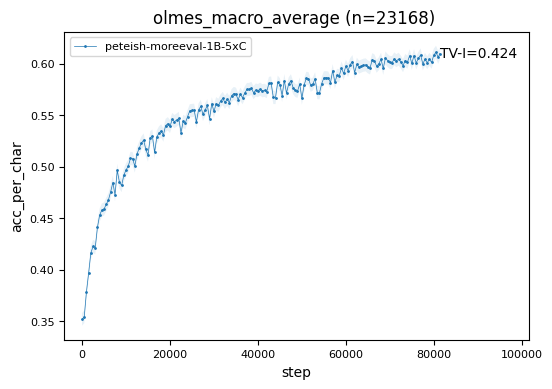

In [77]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)

tv_results, _ = compute_total_variation(
    df, 
    tasks=[olmes],
    models=['peteish-moreeval-1B-5xC'],
    metric='acc_per_char',
    axes=[axes[0][0]]
)

In [79]:
tv_results, _ = compute_total_variation(
    df, 
    tasks=TASKS,
    models=['peteish-moreeval-1B-5xC'],
    metric='acc_per_char',
)

In [80]:
print(f'TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.18,0.28 (+0.10),0.32 (+0.14),0.18 (+0.00)
piqa,0.38,0.36 (-0.02),0.47 (+0.08),0.38 (-0.00)
socialiqa,0.50,0.65 (+0.15),0.95 (+0.45),0.57 (+0.07)
arc_easy,0.52,0.59 (+0.07),0.64 (+0.12),0.43 (-0.09)
csqa,0.56,0.80 (+0.24),0.51 (-0.05),0.67 (+0.10)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.49 (-0.18),0.72 (+0.05)
openbookqa,0.93,0.68 (-0.25),1.31 (+0.38),1.03 (+0.10)
boolq,3.57,3.63 (+0.06),6.09 (+2.52),1.13 (-2.43)


### All 3 Measures

In [81]:
print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

print(f'TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.9%,4.3% (+3.4%),3.9% (+3.0%),3.4% (+2.5%)
piqa,1.0%,18.1% (+17.1%),1.4% (+0.4%),1.5% (+0.6%)
arc_easy,3.1%,2.5% (-0.6%),8.0% (+4.9%),2.6% (-0.5%)
csqa,3.6%,9.2% (+5.6%),2.7% (-0.9%),1.5% (-2.2%)
socialiqa,4.8%,20.3% (+15.5%),2.1% (-2.7%),7.6% (+2.8%)
arc_challenge,5.9%,7.5% (+1.7%),8.3% (+2.5%),6.5% (+0.7%)
openbookqa,7.9%,1.2% (-6.7%),4.3% (-3.7%),9.8% (+1.8%)
boolq,13.9%,11.6% (-2.3%),2.0% (-11.9%),16.1% (+2.2%)
winogrande,26.5%,--,--,20.3% (-6.1%)


% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,89.5%,91.1% (+1.6%),95.3% (+5.8%),84.7% (-4.7%)
hellaswag,86.3%,59.5% (-26.8%),77.9% (-8.4%),79.5% (-6.8%)
csqa,79.5%,81.6% (+2.1%),93.7% (+14.2%),51.6% (-27.9%)
arc_challenge,73.7%,75.3% (+1.6%),90.5% (+16.8%),76.3% (+2.6%)
boolq,70.5%,86.3% (+15.8%),96.3% (+25.8%),78.9% (+8.4%)
socialiqa,55.3%,72.6% (+17.4%),78.4% (+23.2%),41.6% (-13.7%)
openbookqa,48.9%,28.4% (-20.5%),93.2% (+44.2%),48.9% (+0.0%)
piqa,33.2%,16.3% (-16.8%),79.5% (+46.3%),28.4% (-4.7%)
winogrande,23.7%,--,--,23.2% (-0.5%)


TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.18,0.28 (+0.10),0.32 (+0.14),0.18 (+0.00)
piqa,0.38,0.36 (-0.02),0.47 (+0.08),0.38 (-0.00)
socialiqa,0.50,0.65 (+0.15),0.95 (+0.45),0.57 (+0.07)
arc_easy,0.52,0.59 (+0.07),0.64 (+0.12),0.43 (-0.09)
csqa,0.56,0.80 (+0.24),0.51 (-0.05),0.67 (+0.10)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.49 (-0.18),0.72 (+0.05)
openbookqa,0.93,0.68 (-0.25),1.31 (+0.38),1.03 (+0.10)
boolq,3.57,3.63 (+0.06),6.09 (+2.52),1.13 (-2.43)


In [82]:
from ladder import sort_experiment_names
akshita_ladder_models = sort_experiment_names(akshita_ladder_models)

/Users/dhei/ai2/new-evals/analysis/ladder.py:215: UserWarning: Warning: 33719/33729 duplicate native_id-key pairs found for task='autobencher'. Removing duplicates...
  _, scores = get_nd_array(df, "model", metric_names, model=model, task=task_name, step="max")
Computing pairwise comparisons: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


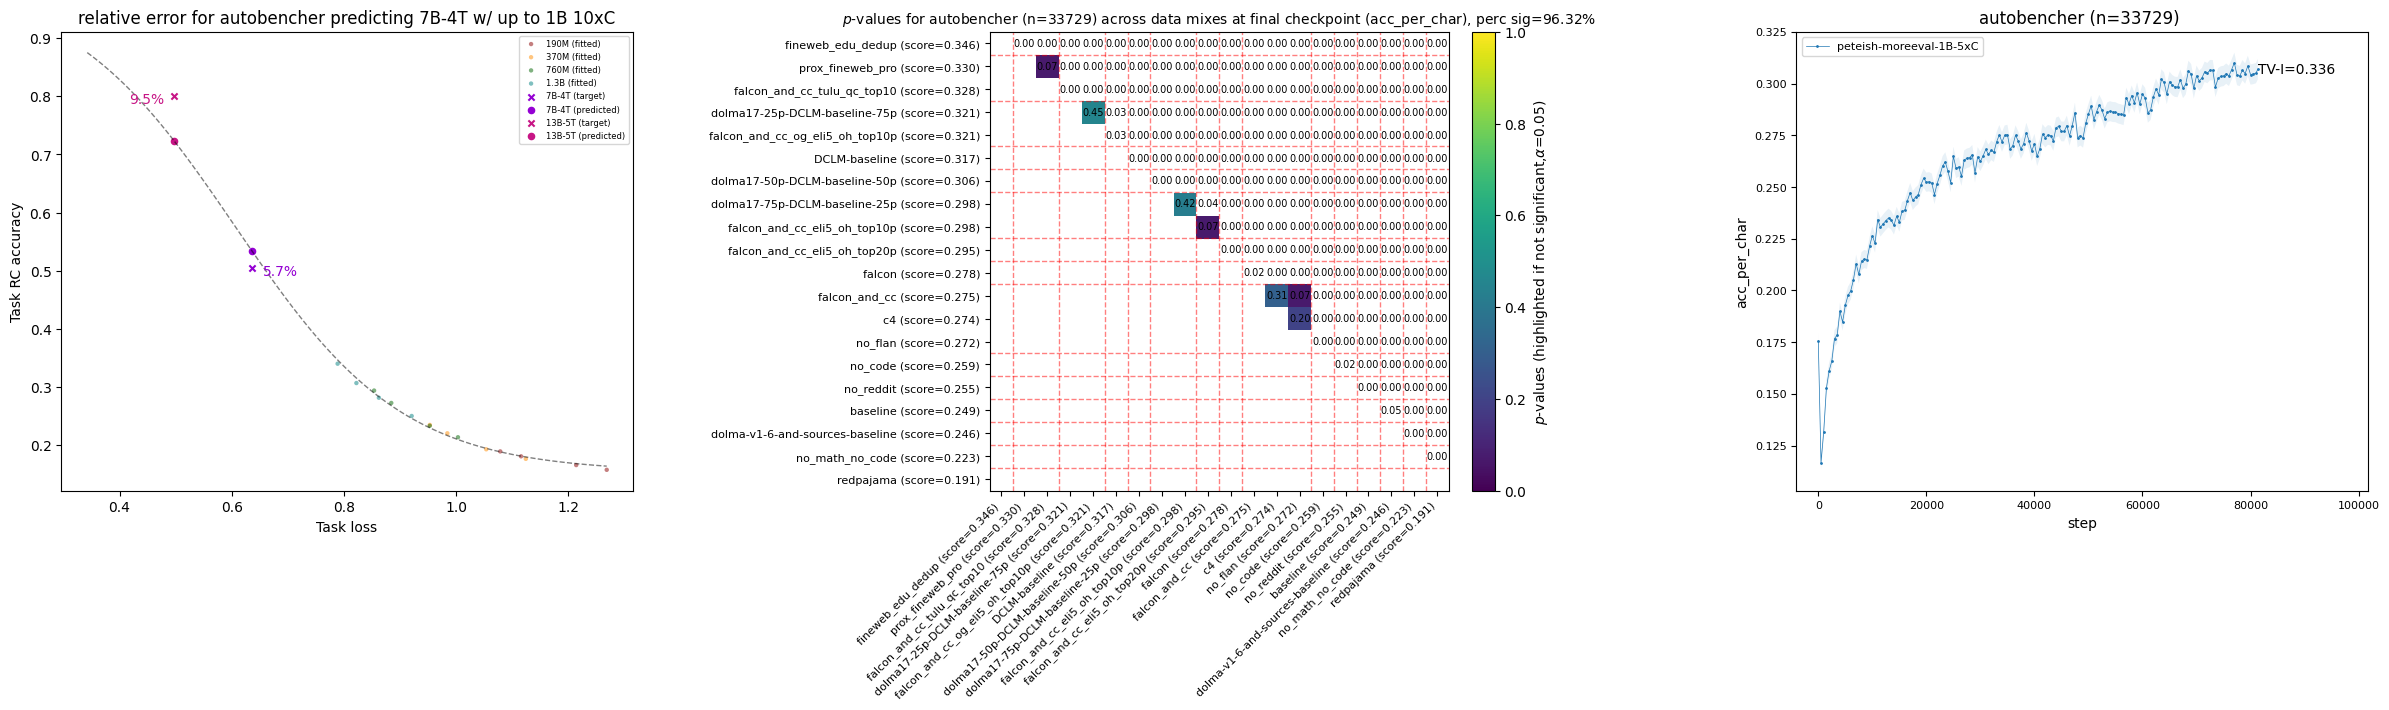

In [85]:
def plot_all_measures(task_name):
    fig, axes = plt.subplots(1, 3, figsize=(8*3, 7), squeeze=False)

    # Measure 1: Predictability
    _, _, _ = run_ladder(
        df,
        task_name=task_name,
        train_models=akshita_ladder_models,
        # eval_models=all_models,
        # eval_models=['peteish13-highlr'],
        eval_models=['peteish7', 'peteish13-highlr'],
        axes=[axes[0][0]],
        config_path=ladder_config_path,
        run_step1=False, run_stacked=False
        # run_step2=False, run_stacked=False
    )
    # _ = axes[0][0].legend(fontsize=6, ncol=2)
    _task_name = task_name if isinstance(task_name, str) else 'aggregate'
    axes[0][0].set_title(f'relative error for {_task_name} predicting 7B-4T w/ up to 1B 10xC')

    # Measure 2: Seperability
    sig_results, _, ax = compute_significance(
        df, 
        models=MODEL_LIST_MIXES, 
        metric='acc_per_char', 
        tasks=[task_name], 
        do_plot=axes[0][1]
    )

    # Measure 3: Smoothness
    tv_results, _ = compute_total_variation(
        df, 
        models=['peteish-moreeval-1B-5xC'],
        # metric='logits_per_char',
        metric='acc_per_char',
        tasks=[task_name],
        axes=[axes[0][2]]
    )

    fig.tight_layout()

    return fig

# _ = plot_all_measures('arc_easy')
# _ = plot_all_measures(olmes)

# _ = plot_all_measures('agi_eval_sat-math:mc')
# _ = plot_all_measures('agi_eval_sat-math:perturb_cot')

# _ = plot_all_measures('agi_eval_aqua-rat:mc')
# _ = plot_all_measures('agi_eval_aqua-rat:perturb_cot')

# _ = plot_all_measures('minerva_math_algebra:perturb_cot')

_ = plot_all_measures('autobencher')

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]


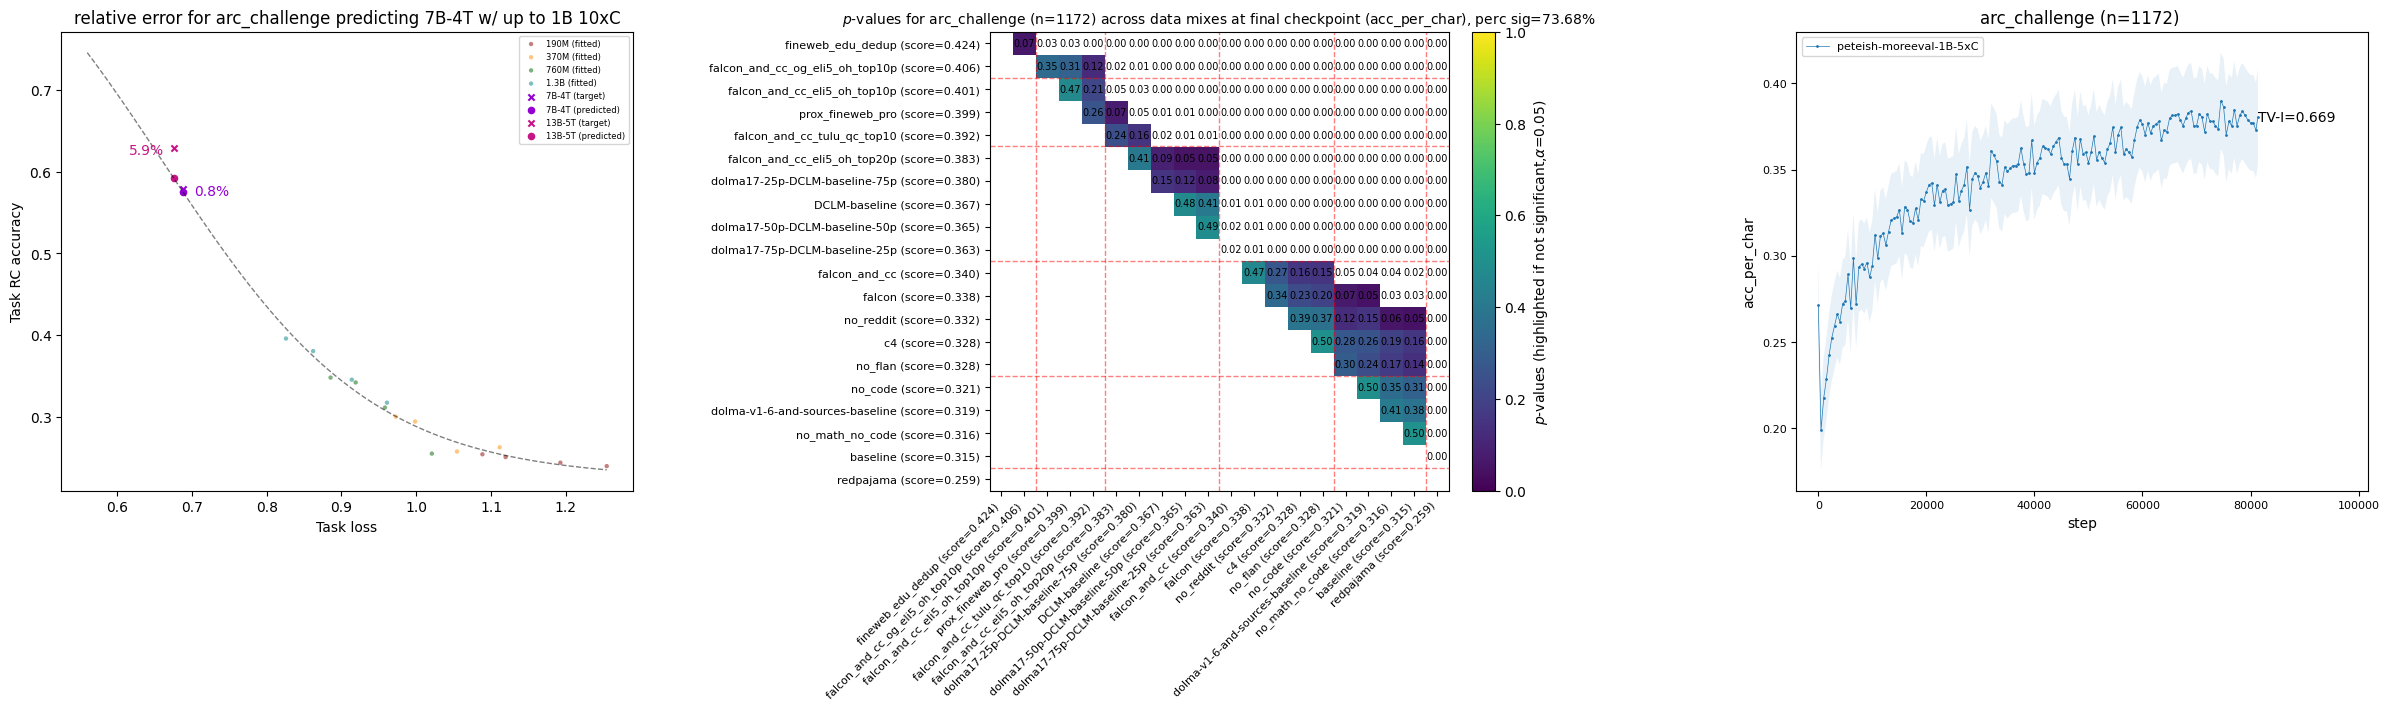

In [86]:
_ = plot_all_measures('arc_challenge')

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]


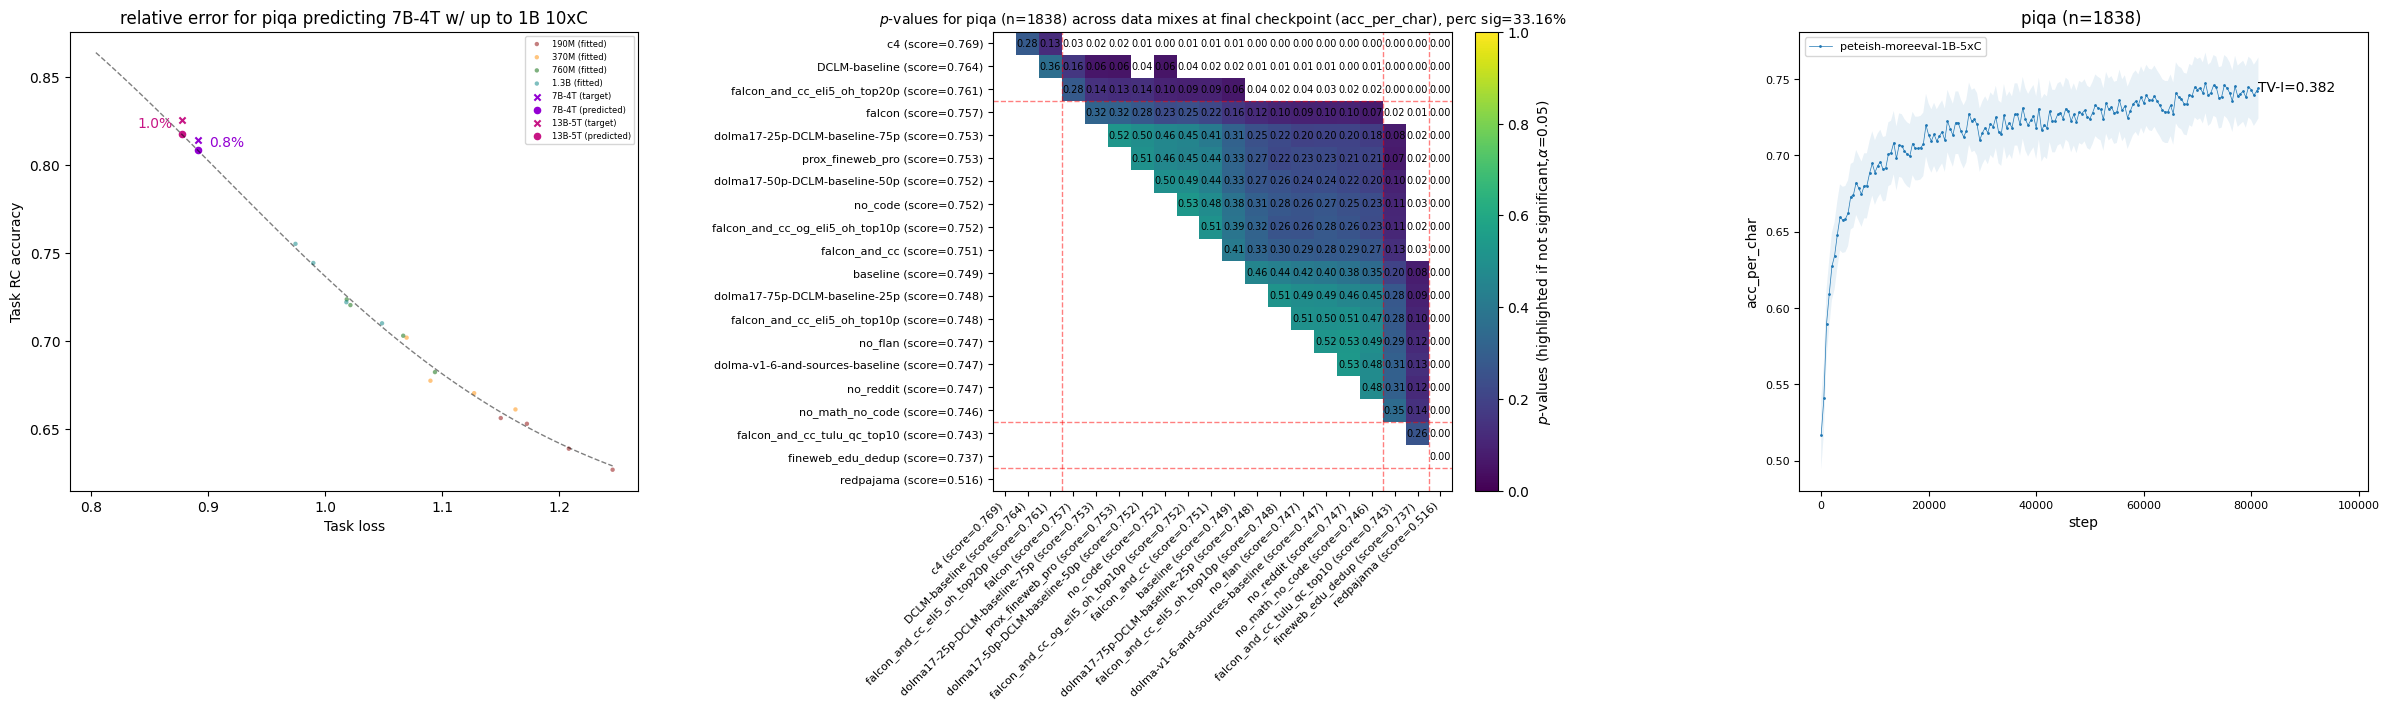

In [87]:
_ = plot_all_measures('piqa')

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  1.37it/s]


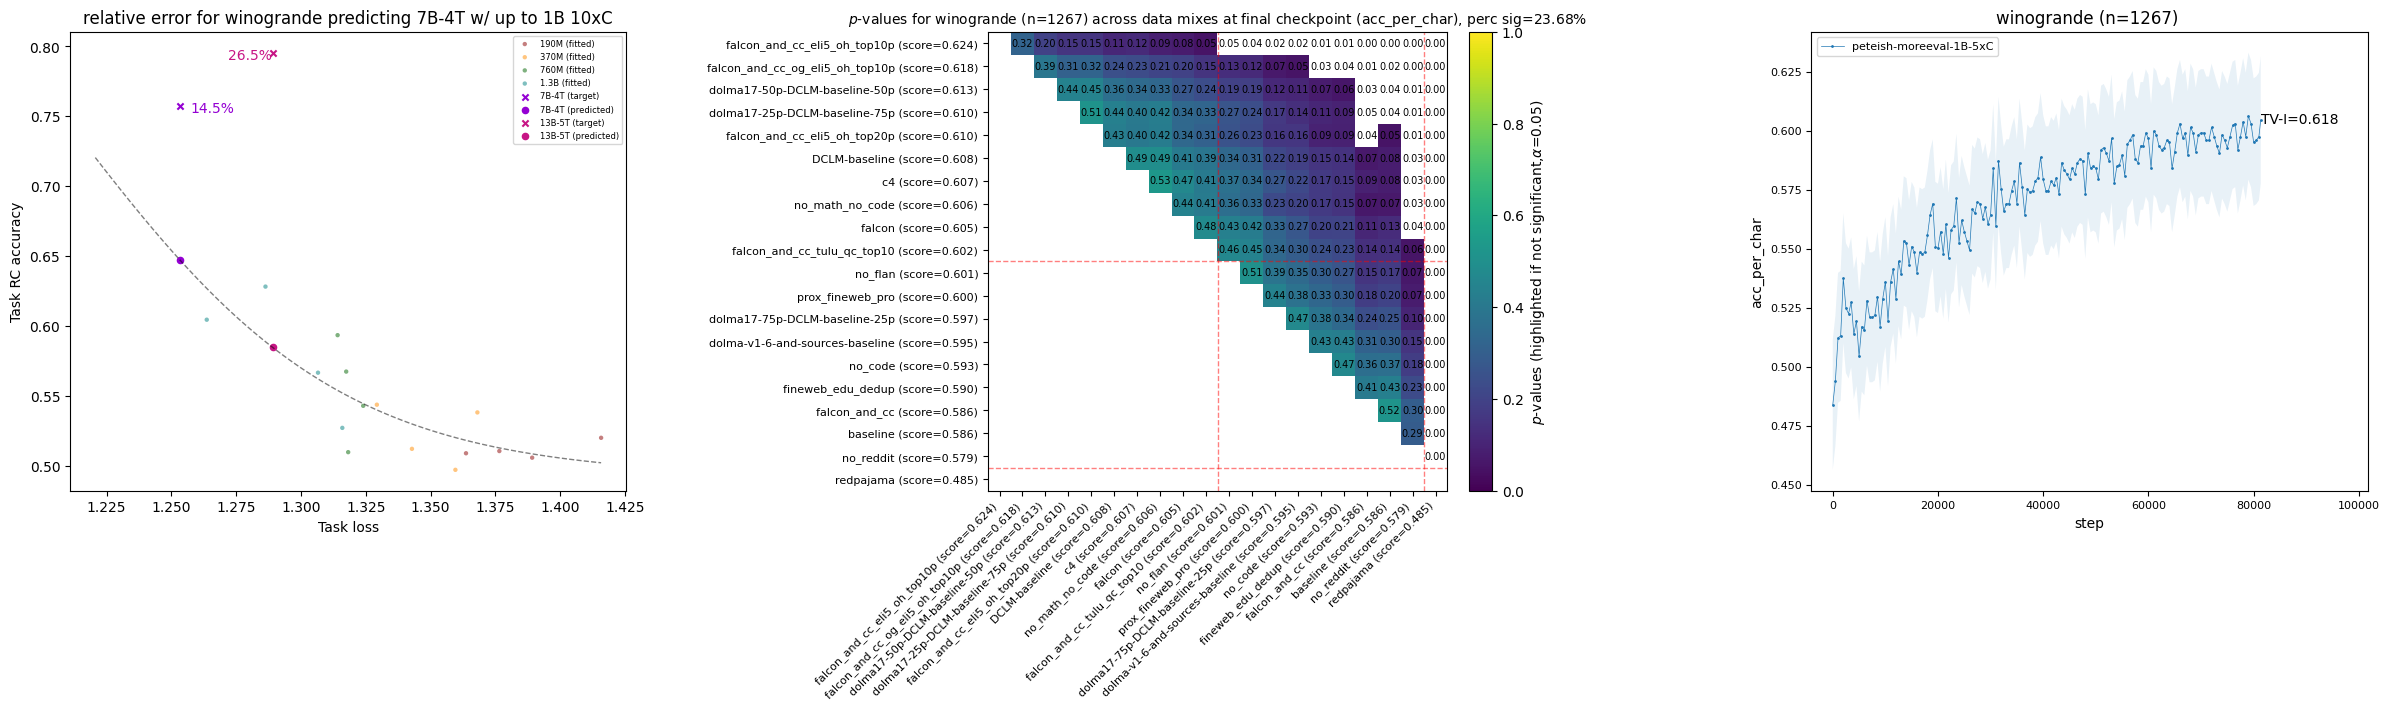

In [88]:
_ = plot_all_measures('winogrande')

### Benchmark Transformations

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


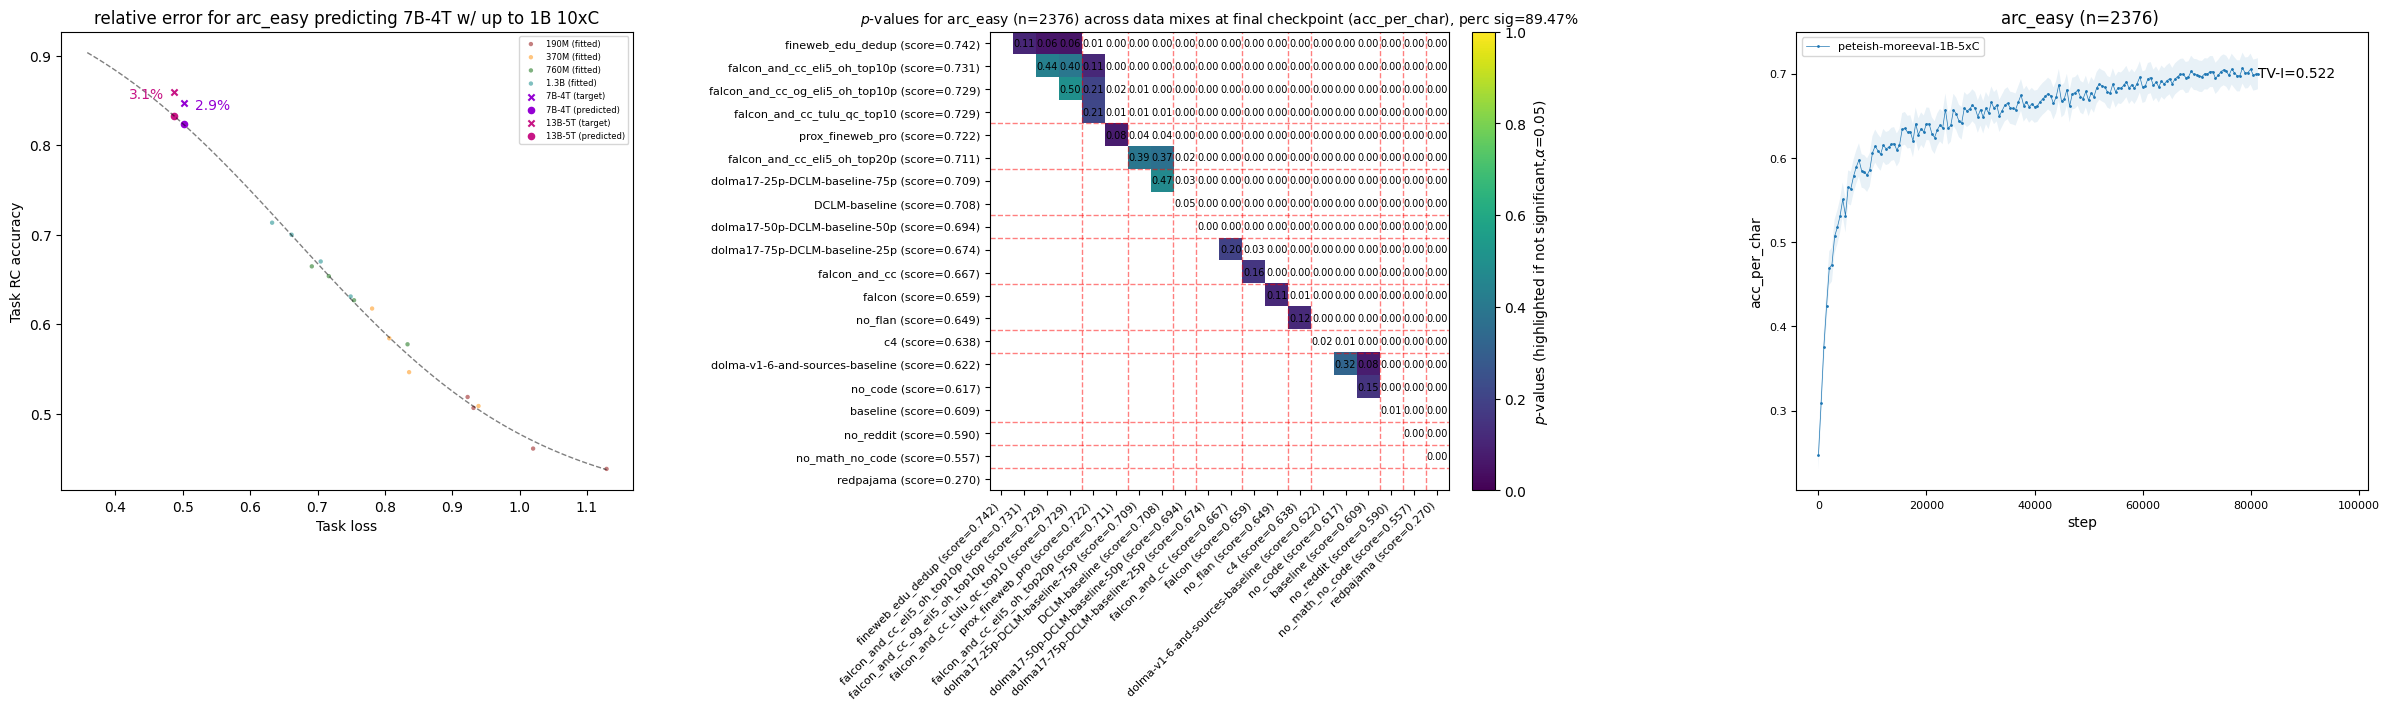

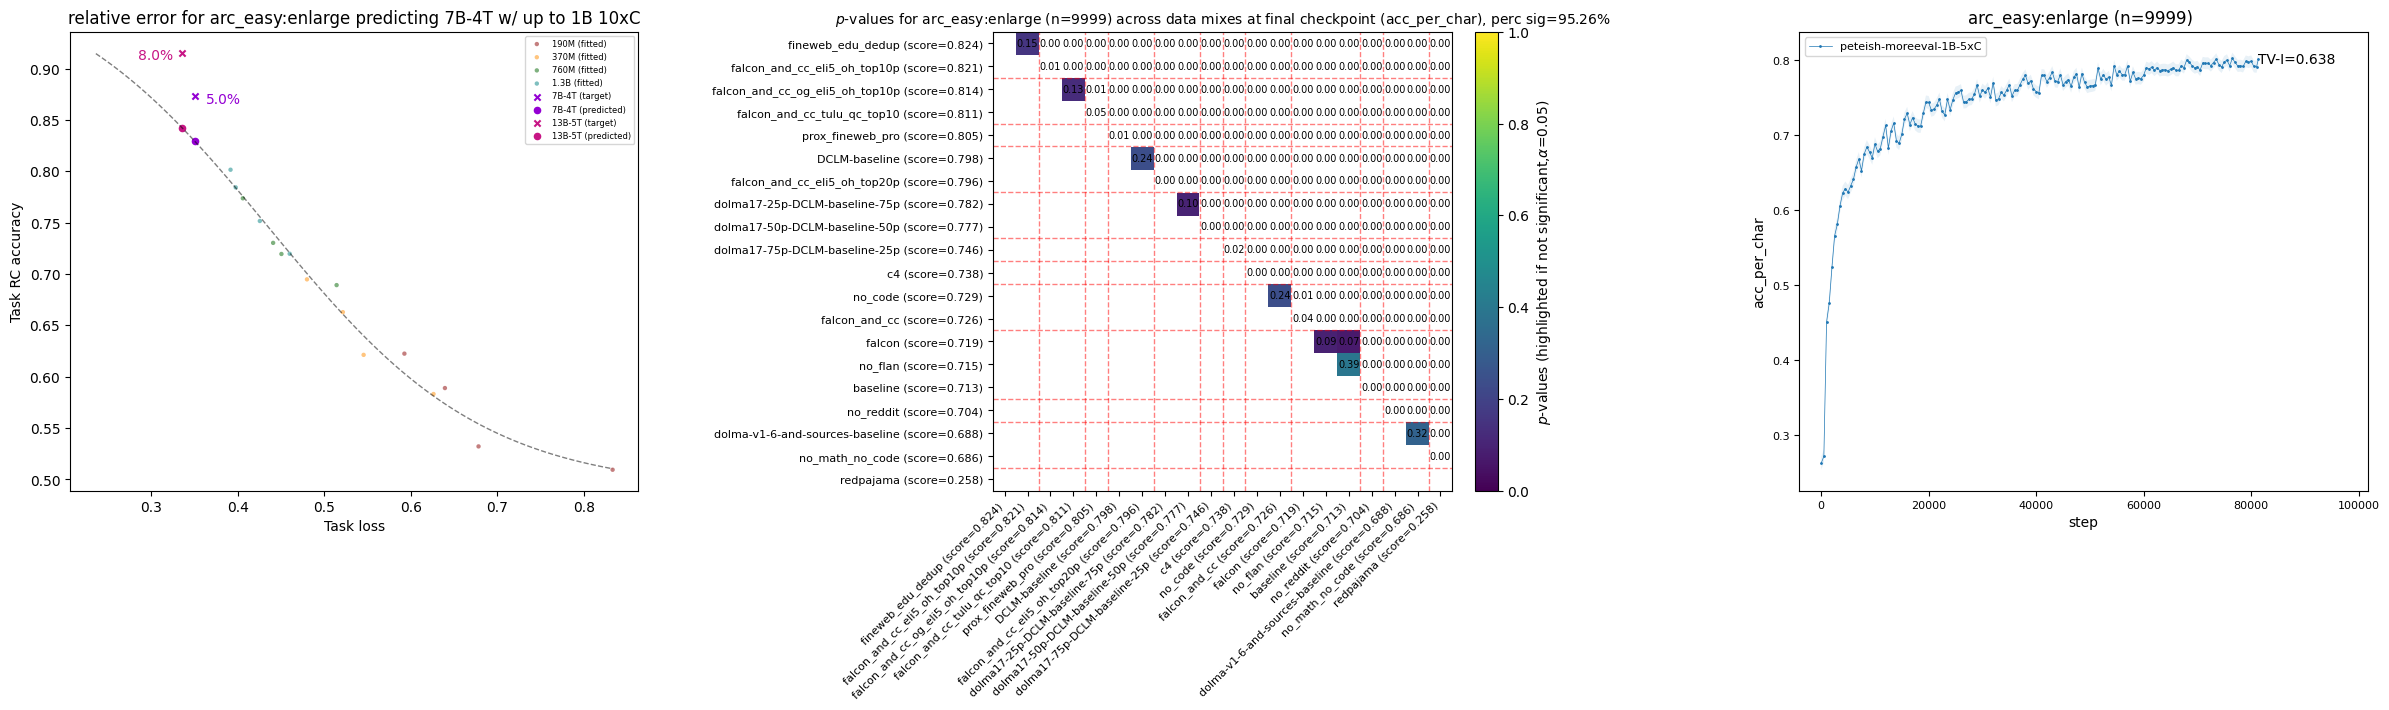

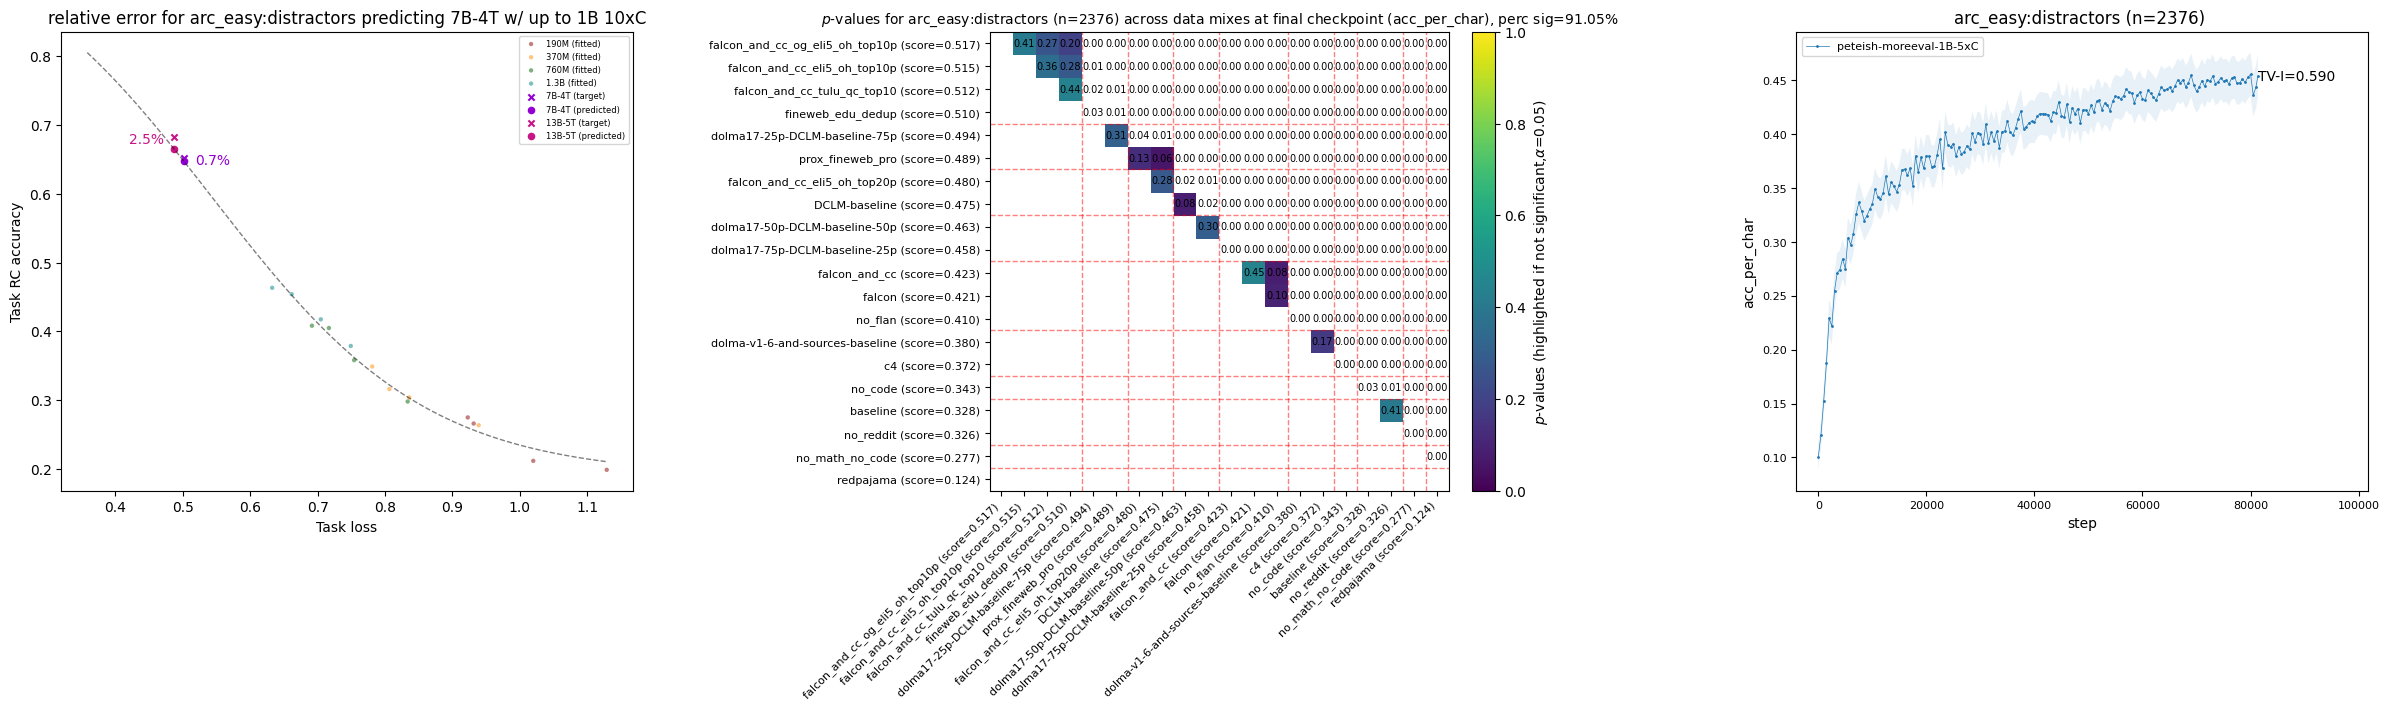

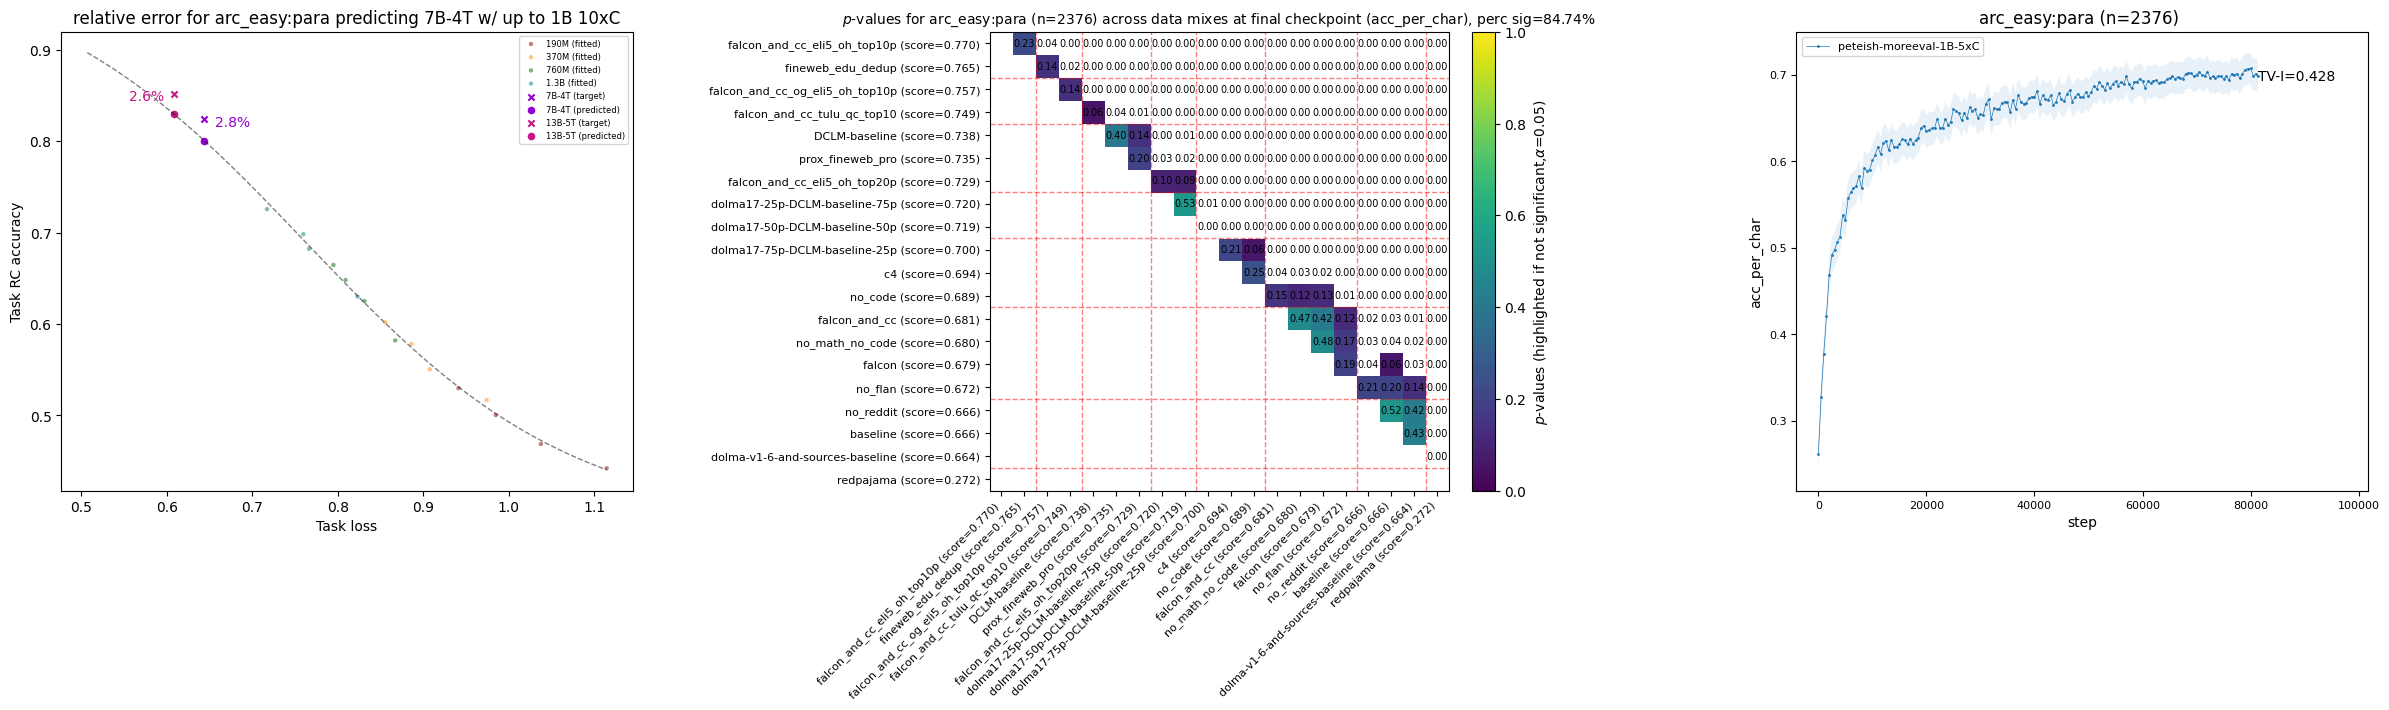

In [89]:
_ = plot_all_measures('arc_easy')
_ = plot_all_measures('arc_easy:enlarge')
_ = plot_all_measures('arc_easy:distractors')
_ = plot_all_measures('arc_easy:para')

### Results on All Tasks

In [30]:
# for task in tqdm(TASKS, desc='Plotting all tasks'):
#     try:
#         _ = plot_all_measures(task)
#     except Exception as e:
#         print(f'{task} failed: {e}')

In [31]:
# TODO: Use bootstrap sampling to see how these numbers change as we increase sample size